# Clustering với k-Means

In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định

**Giả sử có 3 tập**
1. Set 1: 50 điểm
1. Set 2: 75 điểm
1. Set 3: 100 điểm

In [2]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

**=== Hiển thị 3 tập để kiểm tra ===**

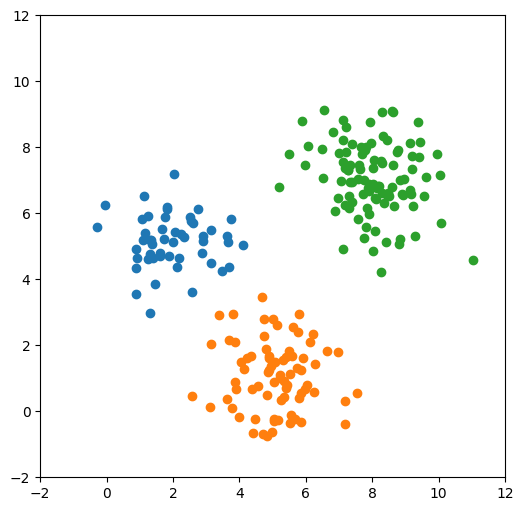

In [3]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập chưa được clustered

In [4]:
dat1 = np.stack([x1, y1]).T
dat2 = np.stack([x2, y2]).T
dat3 = np.stack([x3, y3]).T
dat = np.concatenate([dat1, dat2, dat3])

In [5]:
dat2 = np.stack([x2,y2]).T
dat3 = np.stack([x3,y3]).T

**=== Tập dữ liệu giả định có 225 dòng, 2 cột (x,y) ===**

In [6]:
print(dat.shape)

(225, 2)


### Sắp ngẫu nhiên các dòng

In [7]:
np.random.seed(2)
np.random.shuffle(dat)

### Kiểm tra lại với biểu đồ scatter

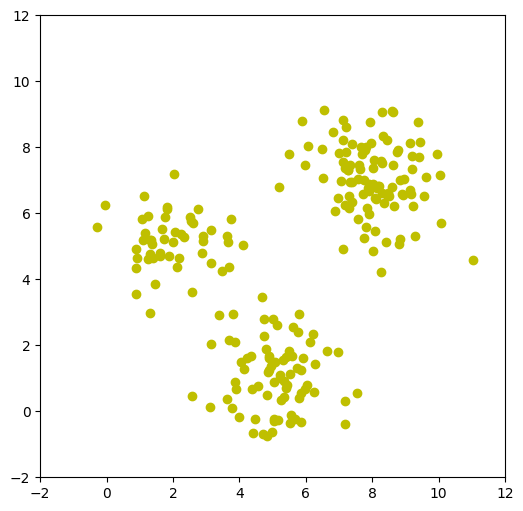

In [8]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.show()

## 2. Thực hiện phân cụm

### 2.1. Giả sử K=3 và tìm 3 điểm ban đầu ngẫu nhiên

In [10]:
K = 3

In [11]:
np.random.seed(30)
centroids = dat[np.random.choice(dat.shape[0], K, replace=False)]
print(centroids)

[[5.338 0.438]
 [2.617 5.698]
 [4.9   1.243]]


**Gán các trung tâm cho 3 điểm này**

In [12]:
centroids = dat[np.random.choice(dat.shape[0], K, replace=False)]

**=== Vẽ K điểm centroids ban đầu lên biểu đồ ===**

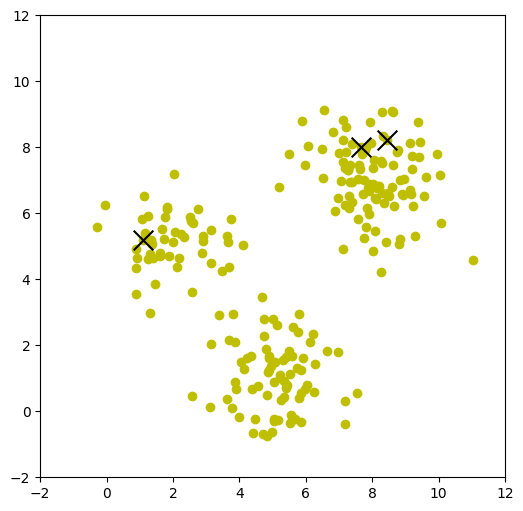

In [13]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k', marker='x', s=200)

plt.show()

### 2.2. Tiến hành gom cụm lần 1

**=== Khởi tạo K danh sách rỗng (để chứa các điểm của mỗi cluster) ===**

In [14]:
cList = [[] for _ in range(K)]

print(cList)

[[], [], []]


**=== Với mỗi sample, tìm xem nó gần điểm centroid nào nhất ===**

In [15]:
for sample in dat:
    d = np.sum((sample - centroids) ** 2, axis=1)
    min_d_idx = np.argmin(d)
    cList[min_d_idx].append(sample)

In [16]:
# Thử kiểm tra lại mỗi list
for i in range(K): print(len(cList[i]))

36
121
68


**=== Thử lấy cluster đầu tiên ra và đánh giá ===**

In [17]:
np.stack(cList[0]).shape

(36, 2)

In [18]:
# Tọa độ của điểm centroid mới
new_centroid = np.stack(cList[0]).mean(axis=0)
print(new_centroid)

[9.01  7.249]


**=== Tính lại các điểm centroids ===**

In [19]:
centroids = np.stack([np.stack(cList[i]).mean(axis=0) for i in range(K)])

print(centroids)

[[9.01  7.249]
 [3.735 2.763]
 [7.435 6.616]]


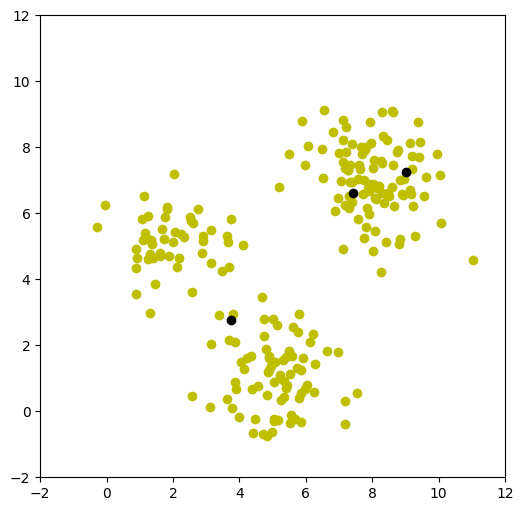

In [20]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.3. Tiến hành gom cụm lần 2

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [21]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

# Tính giá trị của các centroids mới
centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[8.918 7.334]
 [3.842 2.711]
 [7.44  6.891]]


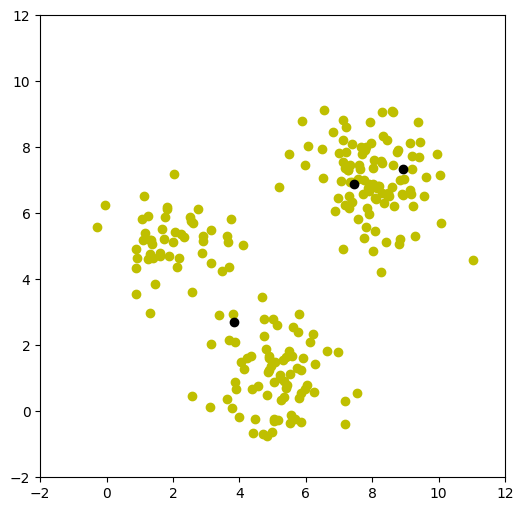

In [22]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.4. Tiến hành gom cụm lần 3

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [23]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[8.944 7.263]
 [3.842 2.711]
 [7.423 6.936]]


**==> Nhận xét: các giá trị trung tâm gần như ít thay đổi**

In [24]:
# Lấy ra các cluster
cluster0 = np.stack(cList[0])
cluster1 = np.stack(cList[1])
cluster2 = np.stack(cList[2])
print(cluster0.shape, cluster1.shape, cluster2.shape)

(39, 2) (125, 2) (61, 2)


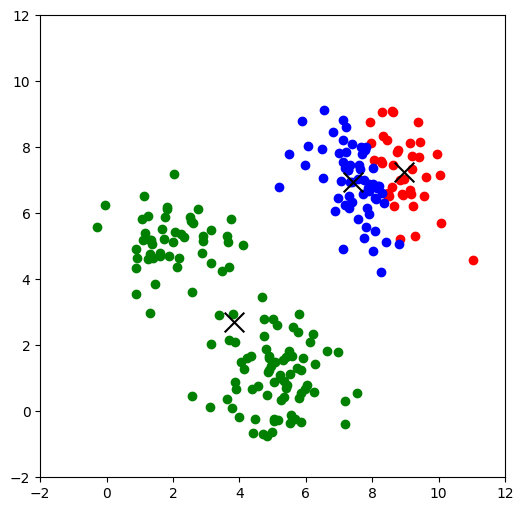

In [26]:
# Hiển thị 3 cluster lên biểu đồ
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

colors = ['r', 'g', 'b']
for i in range(K):
    cluster = np.stack(cList[i])
    plt.scatter(cluster[:,0], cluster[:,1], color=colors[i])

plt.scatter(centroids[:,0], centroids[:,1], color='k', marker='x', s=200)
plt.show()

In [27]:
# Kết thúc demo k-Means
print('k-Means demo completed')

k-Means demo completed
